### Introduction to Simplified Self - Attention (without trainable weights)

1. After input embeddings, we need to calculate how much influence a word (token) contains in the text.
2. To calculate influence we need to calculate attention scores for each token with respect to query (Each word/token taken in a time w.r.t text)

In [1]:
import torch

In [2]:
# Input embedding token vectors
input_token = torch.tensor(
    [
        [0.43, 0.15, 0.89], # Your
        [0.55, 0.87, 0.66], # Jouney
        [0.57, 0.85, 0.64], # Starts
        [0.22, 0.58, 0.33], # With
        [0.77, 0.25, 0.40], # One
        [0.05, 0.80, 0.55], # Step
    ]
)

print(f'Input token dimension: (token_id) * (feature_dims) {input_token.shape}')

Input token dimension: (token_id) * (feature_dims) torch.Size([6, 3])


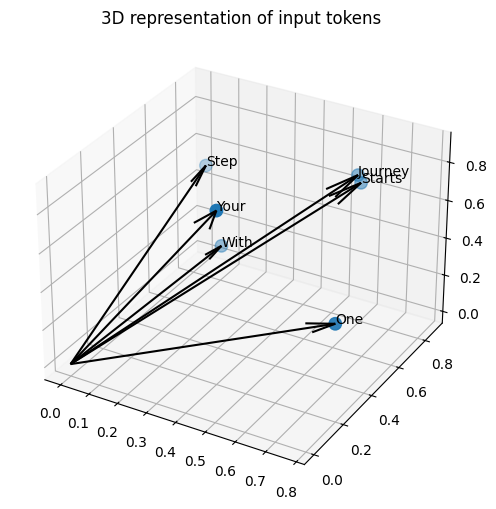

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Representation of input_tokens in 3D point space for visualization
words = ["Your", "Journey", "Starts", "With", "One", "Step"]

# Converting tensor vectors to numpy values to plot graph
points = input_token.numpy()

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection= "3d")

# Points in the vector space
ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=80)

# Get the vector representation for each point
ax.quiver(
    0, 0, 0,
    points[:, 0], points[:, 1], points[:, 2],
    arrow_length_ratio= 0.1,
    color= 'black'
)

# Annotate each points with it's word
for i, word in enumerate(words):
    ax.text(points[i, 0], points[i, 1], points[i, 2], word)

ax.set_title('3D representation of input tokens')
plt.show()

In [4]:
# To calculate attention score, we need to have a query value
query = input_token[1] # Journey (query value)

# This query value will be aligned with other vector representations of text.
# The vector which are aligned in same direction (~0 deg) will have higher attention score.
attention_score = torch.empty(input_token.shape[0])
for i, token in enumerate(input_token):
    attention_score[i] = torch.dot(query, token)

print(attention_score)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.9050, 1.0865])


In [5]:
# Applying normalization of softmax approach to overcome influence of tensor problem
attention_matrix = torch.softmax(attention_score, dim= 0)
print(attention_matrix)

tensor([0.1353, 0.2324, 0.2279, 0.1211, 0.1288, 0.1545])


In [6]:
# Context vector for word "Journey"
# Context vecor = sum(input_token * attention weight)
context_vector_2 = torch.empty(input_token.shape[1])

for i, token_vec in enumerate(input_token):
    context_vector_2 += torch.round(attention_matrix[i] * token_vec, decimals=2)

print(context_vector_2)

tensor([0.6075, 0.6300, 0.5900])


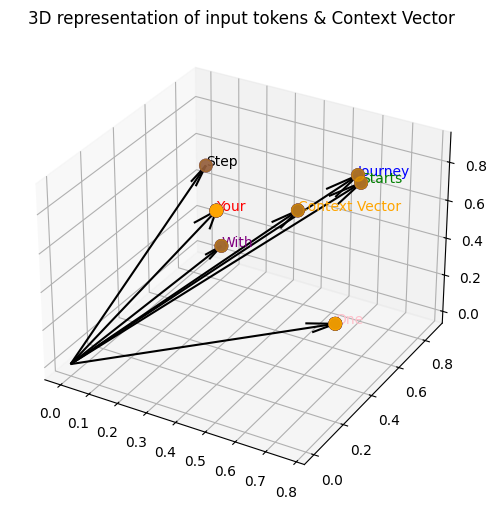

In [7]:
# Visualization of context vector with word "Journey"
# Representation of input_tokens in 3D point space for visualization
words_context = ["Your", "Journey", "Starts", "With", "One", "Step", "Context Vector"]
colors = ["Red", "Blue", "Green", "Purple", "pink", "Black", "Orange"]

inputs = torch.tensor(
    [
        [0.43, 0.15, 0.89], # Your
        [0.55, 0.87, 0.66], # Jouney
        [0.57, 0.85, 0.64], # Starts
        [0.22, 0.58, 0.33], # With
        [0.77, 0.25, 0.40], # One
        [0.05, 0.80, 0.55], # Step
        [0.46, 0.63, 0.59]    # Context Vector
    ]
)

# Converting tensor vectors to numpy values to plot graph
points = inputs.numpy()

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection= "3d")

# Get the vector representation for each point
ax.quiver(
    0, 0, 0,
    points[:, 0], points[:, 1], points[:, 2],
    arrow_length_ratio= 0.1,
    color= 'black'
)

# Annotate each points with it's word
for i, (word, color) in enumerate(zip(words_context, colors)):
    # Points in the vector space
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=80, color=color)
    ax.text(points[i, 0], points[i, 1], points[i, 2], word, color=color, fontsize= 10)

ax.set_title('3D representation of input tokens & Context Vector')
plt.show()

In [8]:
# Implement the similar approach to calculate attention weight matrix for each query

def calculate_attention_weight_V1(input_token):

    # Getting query each token id vectors
    # For each query calculating attention scores (query.values(token_vectors))
    attention_scores = torch.empty(input_token.shape[0], input_token.shape[0])
    for i, query in enumerate(input_token):
        for j, values in enumerate(input_token):
            attention_scores[i][j] = torch.dot(query, values)

    # Normalizing attention_scores with softmax formula (Attention_Weights)
    attention_weights = torch.softmax(attention_scores, dim= 0)

    return attention_weights

# Input embedding vectors
input_tokens = torch.tensor(
    [
        [0.43, 0.15, 0.89], # Your
        [0.55, 0.87, 0.66], # Jouney
        [0.57, 0.85, 0.64], # Starts
        [0.22, 0.58, 0.33], # With
        [0.77, 0.25, 0.40], # One
        [0.05, 0.80, 0.55], # Step
    ]
)

attention_matrix = calculate_attention_weight_V1(input_tokens)
print(attention_matrix)


tensor([[0.2023, 0.1353, 0.1358, 0.1417, 0.1662, 0.1361],
        [0.1934, 0.2324, 0.2315, 0.2047, 0.1991, 0.2146],
        [0.1910, 0.2279, 0.2273, 0.2019, 0.1995, 0.2091],
        [0.1198, 0.1211, 0.1214, 0.1443, 0.1258, 0.1396],
        [0.1537, 0.1288, 0.1312, 0.1376, 0.1820, 0.1145],
        [0.1399, 0.1545, 0.1529, 0.1698, 0.1274, 0.1863]])


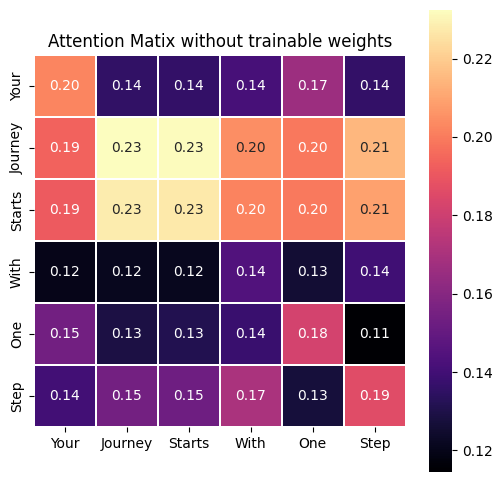

In [9]:
# HeatMap visualization of attention weights with each input embedding vector
import seaborn as sns

plt.figure(figsize=(6, 6))

# Converting tensors into numpy for visualization
numpy_matrix = attention_matrix.numpy()
sns.heatmap(numpy_matrix,
            fmt= ".2f",
            annot= True,
            xticklabels= words,
            yticklabels= words,
            cmap= "magma",
            square= True,
            linewidths= 0.10,
            cbar= True,
            )
plt.title("Attention Matix without trainable weights")
plt.show()

In [10]:
def calculate_attention_weights_V2(input_tokens: torch.Tensor):
    # Defining attention_score matrix (6, 6)
    attention_scores = torch.empty(input_tokens.shape[0], input_tokens.shape[0])

    # Calcuating attention scores without looping
    attention_scores = input_tokens @ input_tokens.T

    #Doing normalization using softmax, such that sum(column elements) = 0
    # i.e, dim = -1 (0, 1) ==> (row, column)
    attention_weights = torch.softmax(attention_scores, dim= -1) #sum of element = 0

    return attention_weights


# Input embedding vectors
input_tokens = torch.tensor(
    [
        [0.43, 0.15, 0.89], # Your
        [0.55, 0.87, 0.66], # Jouney
        [0.57, 0.85, 0.64], # Starts
        [0.22, 0.58, 0.33], # With
        [0.77, 0.25, 0.40], # One
        [0.05, 0.80, 0.55], # Step
    ]
)

attention_matrix = calculate_attention_weights_V2(input_tokens)
print(attention_matrix)


tensor([[0.2023, 0.1934, 0.1910, 0.1198, 0.1537, 0.1399],
        [0.1353, 0.2324, 0.2279, 0.1211, 0.1288, 0.1545],
        [0.1358, 0.2315, 0.2273, 0.1214, 0.1312, 0.1529],
        [0.1417, 0.2047, 0.2019, 0.1443, 0.1376, 0.1698],
        [0.1662, 0.1991, 0.1995, 0.1258, 0.1820, 0.1274],
        [0.1361, 0.2146, 0.2091, 0.1396, 0.1145, 0.1863]])


In [13]:
# Calcuating Context Vector for each input token vector
context_vectors = attention_matrix @ input_tokens
print(f'Final Context vector (without trainable) \n {context_vectors}')

Final Context vector (without trainable) 
 tensor([[0.4539, 0.5807, 0.6078],
        [0.4495, 0.6422, 0.5961],
        [0.4506, 0.6404, 0.5957],
        [0.4348, 0.6249, 0.5865],
        [0.4689, 0.5881, 0.5914],
        [0.4239, 0.6434, 0.5908]])


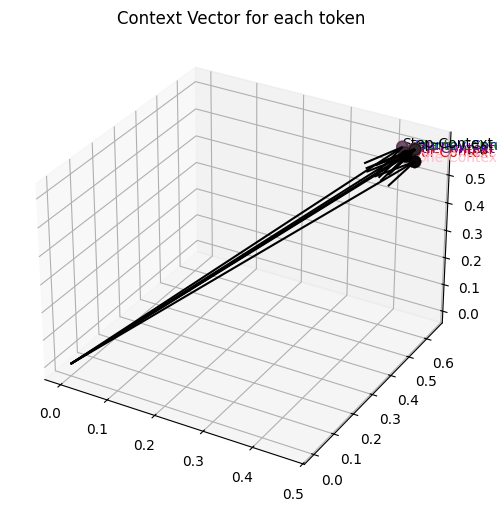

In [14]:
# Visualization of context vector with each tokens
# Representation of input_tokens in 3D point space for visualization
words_context = ["Your-Context", "Journey-Context", "Starts-Context", "With-Context", "One-Context", "Step-Context"]
colors = ["Red", "Blue", "Green", "Purple", "pink", "Black"]

# Converting context vectors to numpy
points = context_vectors.numpy()

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection= "3d")

# Giving vectors to point from origin
ax.quiver(
    0, 0, 0,
    points[:, 0], points[:, 1], points[:, 2],
    arrow_length_ratio= 0.1,
    color= "black"
)

# enumerate and ziping the words_context with colors
for i, (word, color) in enumerate(zip(words_context, colors)):
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s= 70, color=color)
    ax.text(points[i, 0], points[i, 1], points[i, 2], word, color=color, fontsize= 10)

# Title of visualization
plt.title("Context Vector for each token")
plt.show()